In [1]:
import numpy as np
import matplotlib.pyplot as plt
import requests
import os
from google.colab import userdata
from google.colab import drive
drive.mount('/content/drive')
import json
import glob
import cv2
from scipy import signal
from scipy.spatial.distance import cdist
from scipy.spatial import KDTree
from scipy import stats
from scipy.stats import t
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

Mounted at /content/drive


In [2]:
tng_api_key = userdata.get('TNG_API_KEY')
baseUrl = 'http://www.tng-project.org/api/'
headers = {"api-key":tng_api_key}

In [3]:
def get(path, params=None, out_filename=None):
    headers = {"api-key":tng_api_key}
    r = requests.get(path, params=params, headers=headers)
    r.raise_for_status()

    if out_filename is not None:
        with open(out_filename, 'wb') as f:
            f.write(r.content)
        return out_filename

    if r.headers['content-type'] == 'application/json':
        return r.json()

    if 'content-disposition' in r.headers:
        filename = r.headers['content-disposition'].split("filename=")[1]
        with open(filename, 'wb') as f:
            f.write(r.content)
        return filename

    return r

In [4]:
r = get(baseUrl)

for simulation in r['simulations']: #only get TNG50
    if simulation['name'] == 'TNG50-1':
        url = simulation['url']
        break

tng50 = get(url)

url = 'http://www.tng-project.org/api/TNG50-1/snapshots/z=1.8/'
snapshot = get(url)

sub_url = f"http://www.tng-project.org/api/TNG50-1/snapshots/{snapshot['number']}/subhalos/0/"
subhalo = get(sub_url)


--------------------------------------------------------------------------------

In [5]:
vis_queries = [
    ("bfieldx", "partField=bfield_x&ctName=viridis&size=20&sizeType=kpc"),
    ("bfieldy", "partField=bfield_y&ctName=viridis&size=20&sizeType=kpc"),
    ("bfieldz", "partField=bfield_z&ctName=viridis&size=20&sizeType=kpc")
]
for i in range(100):
    print("i: ",i)
    for bfield_name, vis_query in vis_queries:
        bfield_url = f"http://www.tng-project.org/api/TNG50-2/snapshots/34/subhalos/{i}/vis.png?{vis_query}"
        try:
            get(bfield_url, out_filename=f'{bfield_name}_sub{i}.png')
        except Exception as e:
            print(f"sub{i} didn't work for {bfield_name}: {e}")

i:  0
i:  1
i:  2
i:  3
i:  4
i:  5
i:  6
i:  7
i:  8
i:  9
i:  10
i:  11
i:  12
i:  13
i:  14
i:  15
i:  16
i:  17
i:  18
i:  19
i:  20
i:  21
i:  22
i:  23
i:  24
i:  25
i:  26
i:  27
i:  28
i:  29
i:  30
i:  31
i:  32
i:  33
i:  34
i:  35
i:  36
i:  37
i:  38
i:  39
i:  40
i:  41
i:  42
i:  43
i:  44
i:  45
i:  46
i:  47
i:  48
i:  49
i:  50
i:  51
i:  52
i:  53
i:  54
i:  55
i:  56
i:  57
i:  58
i:  59
i:  60
i:  61
i:  62
i:  63
i:  64
i:  65
i:  66
i:  67
i:  68
i:  69
i:  70
i:  71
i:  72
i:  73
i:  74
i:  75
i:  76
i:  77
i:  78
i:  79
i:  80
i:  81
i:  82
i:  83
i:  84
i:  85
i:  86
i:  87
i:  88
i:  89
i:  90
i:  91
i:  92
i:  93
i:  94
i:  95
i:  96
i:  97
i:  98
i:  99


In [6]:
min = -6000
max = 7500
bfield_means= []

for i in range(100):
    results = {}
    for bfield in ["bfieldx", "bfieldy", "bfieldz"]:
        img = cv2.imread(f"{bfield}_sub{i}.png")
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        cbar = img_rgb[100:-100, 1220:-140]
        area = img_rgb[100:-100, 200:1200]

        color = np.mean(cbar, axis=1)
        num = len(color)
        flat = area.reshape(-1,3)
        tree = KDTree(color)
        distances, indices = tree.query(flat)
        estimate = max - (indices/num)*(max-min)
        results[bfield] = estimate.reshape(area.shape[0], area.shape[1])

    bfield_mag = np.sqrt(results["bfieldx"]**2 + results["bfieldy"]**2 + results["bfieldz"]**2)
    mean_bfield = np.mean(bfield_mag)
    bfield_means.append(mean_bfield)

np.savetxt("bfield_means.txt", bfield_means)

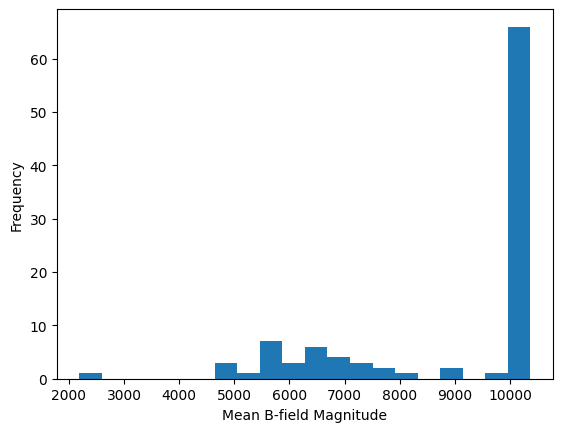

In [12]:
plt.hist(bfield_means, bins=20)
plt.xlabel('Mean B-field Magnitude')
plt.ylabel('Frequency')
plt.show()

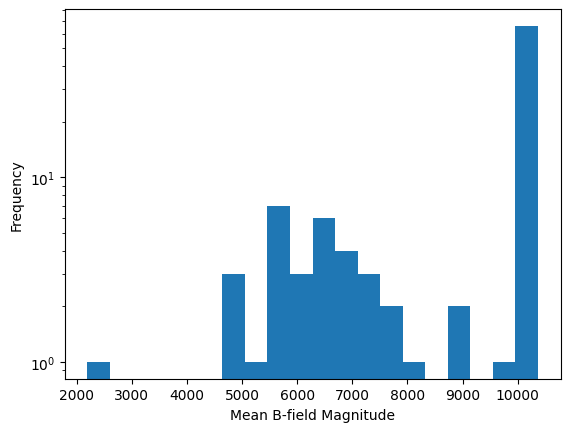

In [13]:
plt.hist(bfield_means, bins=20)
plt.xlabel('Mean B-field Magnitude')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()